# NBA Analytics Storytelling Workshop

Does playing at home actually have an advantage, and if so how big is it?

In this notebook you'll work with 10 seasons of NBA game data to find out. The first few sections walk you through the basics. After that, it's your turn to explore the data and turn it into a story.

## Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per team per game, for the last 10 NBA regular seasons.
games = pd.read_csv("nba_data.csv")

games.head()

,SEASON,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,IS_HOME,WL,PTS,PLUS_MINUS
0,2015-16,ATL,21500001,2015-10-27,ATL vs. DET,True,L,94,-12
1,2015-16,CLE,21500002,2015-10-27,CLE @ CHI,False,L,95,-2
2,2015-16,NOP,21500003,2015-10-27,NOP @ GSW,False,L,95,-16
3,2015-16,CHI,21500002,2015-10-27,CHI vs. CLE,True,W,97,2
4,2015-16,GSW,21500003,2015-10-27,GSW vs. NOP,True,W,111,16


In [2]:
# How many rows, seasons, and columns do we have
print(games.shape)
print(games["SEASON"].unique())
games.info()

(23958, 9)
['2015-16' '2016-17' '2017-18' '2018-19' '2019-20' '2020-21' '2021-22'
 '2022-23' '2023-24' '2024-25']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23958 entries, 0 to 23957
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SEASON             23958 non-null  object
 1   TEAM_ABBREVIATION  23958 non-null  object
 2   GAME_ID            23958 non-null  int64 
 3   GAME_DATE          23958 non-null  object
 4   MATCHUP            23958 non-null  object
 5   IS_HOME            23958 non-null  bool  
 6   WL                 23958 non-null  object
 7   PTS                23958 non-null  int64 
 8   PLUS_MINUS         23958 non-null  int64 
dtypes: bool(1), int64(3), object(5)
memory usage: 1.5+ MB


## 1. How often do home teams win?

Across all 10 seasons, what percentage of home games were won by the home team?

In [3]:
# Keep only the rows where the team was playing at home
home_games = games[games["IS_HOME"]]

# WL == "W" is true/false for every row. Taking the mean gives you the proportion of true values
home_win_rate = (home_games["WL"] == "W").mean()

print(f"Home teams won {home_win_rate:.1%} of games over the last 10 seasons")

Home teams won 56.6% of games over the last 10 seasons


## 2. Has home win rate changed season to season?

The pattern is the same as Part 1, we're just doing it once per season.

SEASON
2015-16    0.588618
2016-17    0.583740
2017-18    0.578862
2018-19    0.592683
2019-20    0.551464
2020-21    0.543519
2021-22    0.543902
2022-23    0.580488
2023-24    0.543089
2024-25    0.544490
Name: WL, dtype: float64


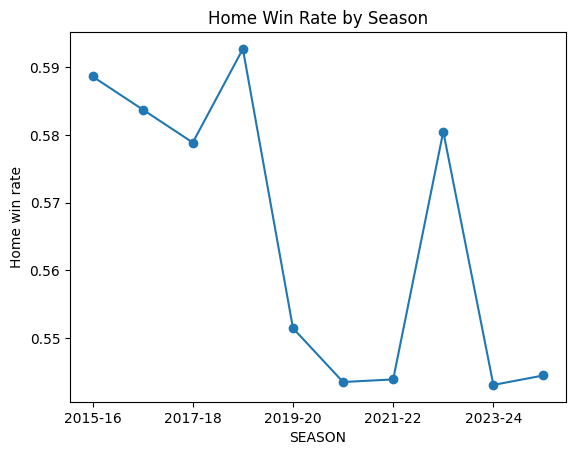

In [6]:
# Group home_games by "SEASON", and for each season compute the home win rate.
win_rate_by_season = home_games.groupby("SEASON")["WL"].apply(lambda wl: (wl == "")) #TODO

print(win_rate_by_season)

# Plot win_rate_by_season as a line chart
win_rate_by_season.plot(kind="line", marker="o", title="Home Win Rate by Season")
plt.ylabel() #TODO
plt.show()

## 3. How big is the scoring margin at home?

Same pattern as Step 2, different column.

SEASON
2015-16    2.674797
2016-17    3.148780
2017-18    2.105691
2018-19    2.724390
2019-20    2.130312
2020-21    0.943519
2021-22    1.722764
2022-23    2.500000
2023-24    2.146341
2024-25    1.692245
Name: PLUS_MINUS, dtype: float64


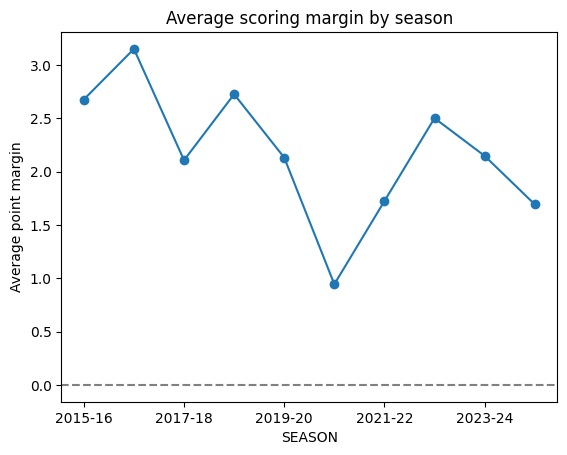

In [7]:
# Group home_games by season and take the mean of "PLUS_MINUS" for each season
margin_by_season = home_games.groupby(" ")[" "].mean() #TODO

print() #TODO

margin_by_season.plot(kind="line", marker="o", title=" ") #TODO
plt.ylabel("Average point margin")
plt.axhline(0, color="gray", linestyle="--")
plt.show()

## 4. Your turn

From here, the notebook is open. games and home_games are still available to you, use them to dig deeper. Some directions to consider:

- **How much did home advantage drop, and did it recover after?** Hint: this is the same season-by-season groupby pattern just for a smaller range of seasons (e.g. `win_rate_by_season.loc["2018-19":"2022-23"]`)

- **Does home advantage differ a lot by team? (Some arenas are known for loud crowds)** Hint: same pattern, but group by "TEAM_ABBREVIATION" instead of "SEASON" (e.g. `home_games.groupby("TEAM_ABBREVIATION")["WL"].apply(...)`)

- **Is home advantage bigger in close games, or does it show up more in blowouts?** Hint: filter rows by how close the game was using the PLUS_MINUS column.
Try something like:

`close_games = home_games[home_games["PLUS_MINUS"].abs() <= 5]`

`blowouts = home_games[home_games["PLUS_MINUS"].abs() >= 20]`


Use the empty cells below for your exploration. When you're done, write a short summary of your findings in the markdown cell at the bottom.

## Your story

*3-4 bullet points on what you found, what surprised you, and what you'd want to look into next.*

-
-
-